In [ ]:
# FILE: 03_Visualize_Results.ipynb
# CELL 1: Setup & Data Loading

from google.colab import drive
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

drive.mount('/content/drive', force_remount=True)
%cd "/content/drive/MyDrive/IndiaProject_Colab"

# Paths
LINEAR_FILE = "results/FINAL_HIERARCHICAL_metrics.parquet"
QUAD_FILE   = "results/FINAL_HIERARCHICAL_QUADRATIC_metrics.parquet"

print("--- Model Comparison: Linear vs. Quadratic ---")

# 1. Load Data
try:
    df_lin = pd.read_parquet(LINEAR_FILE)
    df_quad = pd.read_parquet(QUAD_FILE)
    print(f"[✓] Loaded Linear Results: {len(df_lin)} records")
    print(f"[✓] Loaded Quadratic Results: {len(df_quad)} records")
except FileNotFoundError as e:
    raise SystemExit(f"Missing Files: {e}")

# 2. Filter for Shift 0 (Planting Year) ONLY
# We established Shift 0 is the correct timeline, so we only compare models on that basis.
df_lin = df_lin[df_lin['year_shift'] == 0].copy()
df_quad = df_quad[df_quad['year_shift'] == 0].copy()

# 3. Merge for Head-to-Head Comparison
# Inner Join: We only compare districts that exist in BOTH models.
# (Note: Quadratic model dropped districts with <15 years, so this filters to the robust subset)
merged = pd.merge(
    df_lin,
    df_quad,
    on=['Dist Code', 'crop'],
    suffixes=('_lin', '_quad'),
    how='inner'
)

print(f"--- Comparison Set: {len(merged)} district-crop pairs (Shift 0) ---")
print(f"    (Districts with <15 years of data were dropped by the Quadratic model)")

Mounted at /content/drive
/content/drive/MyDrive/IndiaProject_Colab
--- Model Comparison: Linear vs. Quadratic ---
[✓] Loaded Linear Results: 2504 records
[✓] Loaded Quadratic Results: 2324 records
--- Comparison Set: 788 district-crop pairs (Shift 0) ---
    (Districts with <15 years of data were dropped by the Quadratic model)


--- Reliability Test: Cross-Validation (R²_cv) ---


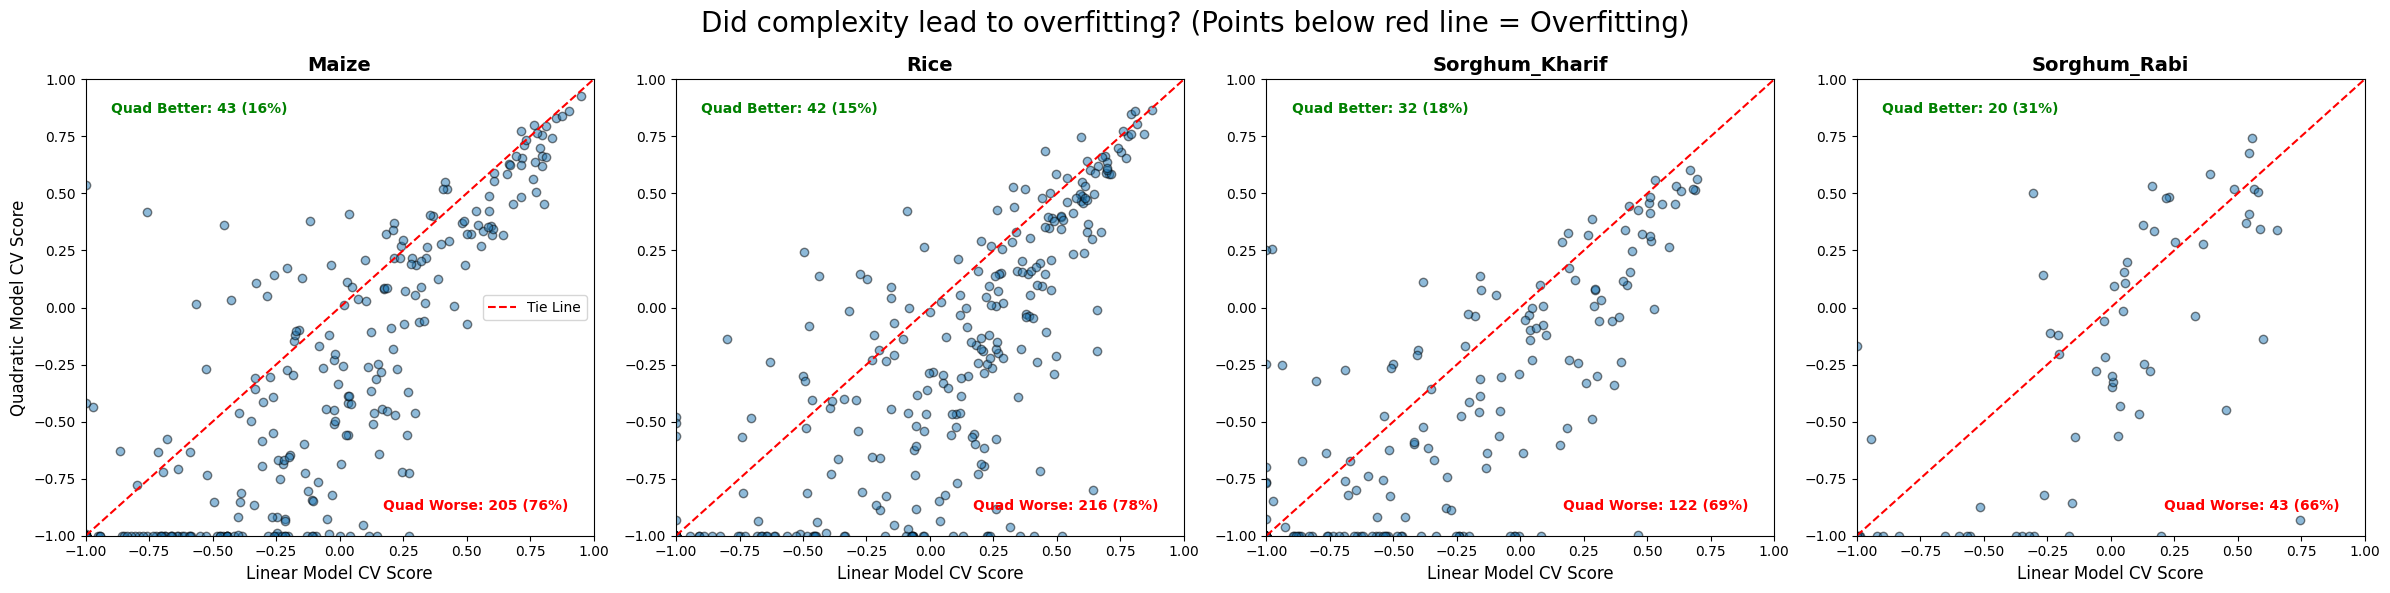

In [ ]:
# FILE: 03_Visualize_Results.ipynb
# CELL 2: The Reliability Test (Cross-Validation)

# QUESTION: Did adding X^2 terms break the model (Overfitting)?
# METRIC: R2_cv (Cross Validation Score)
# LOGIC:
#   - If Quad CV > Linear CV -> Real Improvement.
#   - If Quad CV < Linear CV -> Overfitting (Memorized noise).

print("--- Reliability Test: Cross-Validation (R²_cv) ---")

crops = ['maize', 'rice', 'sorghum_kharif', 'sorghum_rabi']
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for i, crop in enumerate(crops):
    ax = axes[i]
    data = merged[merged['crop'] == crop]

    # Scatter
    ax.scatter(data['R2_cv_lin'], data['R2_cv_quad'], alpha=0.5, edgecolor='k', c='#1f77b4')

    # 1:1 Line
    lims = [
        min(data[['R2_cv_lin', 'R2_cv_quad']].min().min(), -1), # Cap min at -1 for visibility
        max(data[['R2_cv_lin', 'R2_cv_quad']].max().max(), 1)
    ]
    ax.plot(lims, lims, 'r--', label='Tie Line')

    # Styling
    ax.set_title(f"{crop.title()}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Linear Model CV Score", fontsize=12)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    if i == 0:
        ax.set_ylabel("Quadratic Model CV Score", fontsize=12)
        ax.legend()

    # Stats
    wins = (data['R2_cv_quad'] > data['R2_cv_lin']).sum()
    loss = (data['R2_cv_quad'] < data['R2_cv_lin']).sum()
    total = len(data)

    ax.text(0.05, 0.95, f"Quad Better: {wins} ({wins/total:.0%})",
            transform=ax.transAxes, color='green', fontweight='bold', va='top')
    ax.text(0.95, 0.05, f"Quad Worse: {loss} ({loss/total:.0%})",
            transform=ax.transAxes, color='red', fontweight='bold', ha='right', va='bottom')

plt.suptitle("Did complexity lead to overfitting? (Points below red line = Overfitting)", fontsize=20, y=0.98)
plt.tight_layout()
plt.show()

--- Sensitivity Test: Marginal Gain of Climate ---


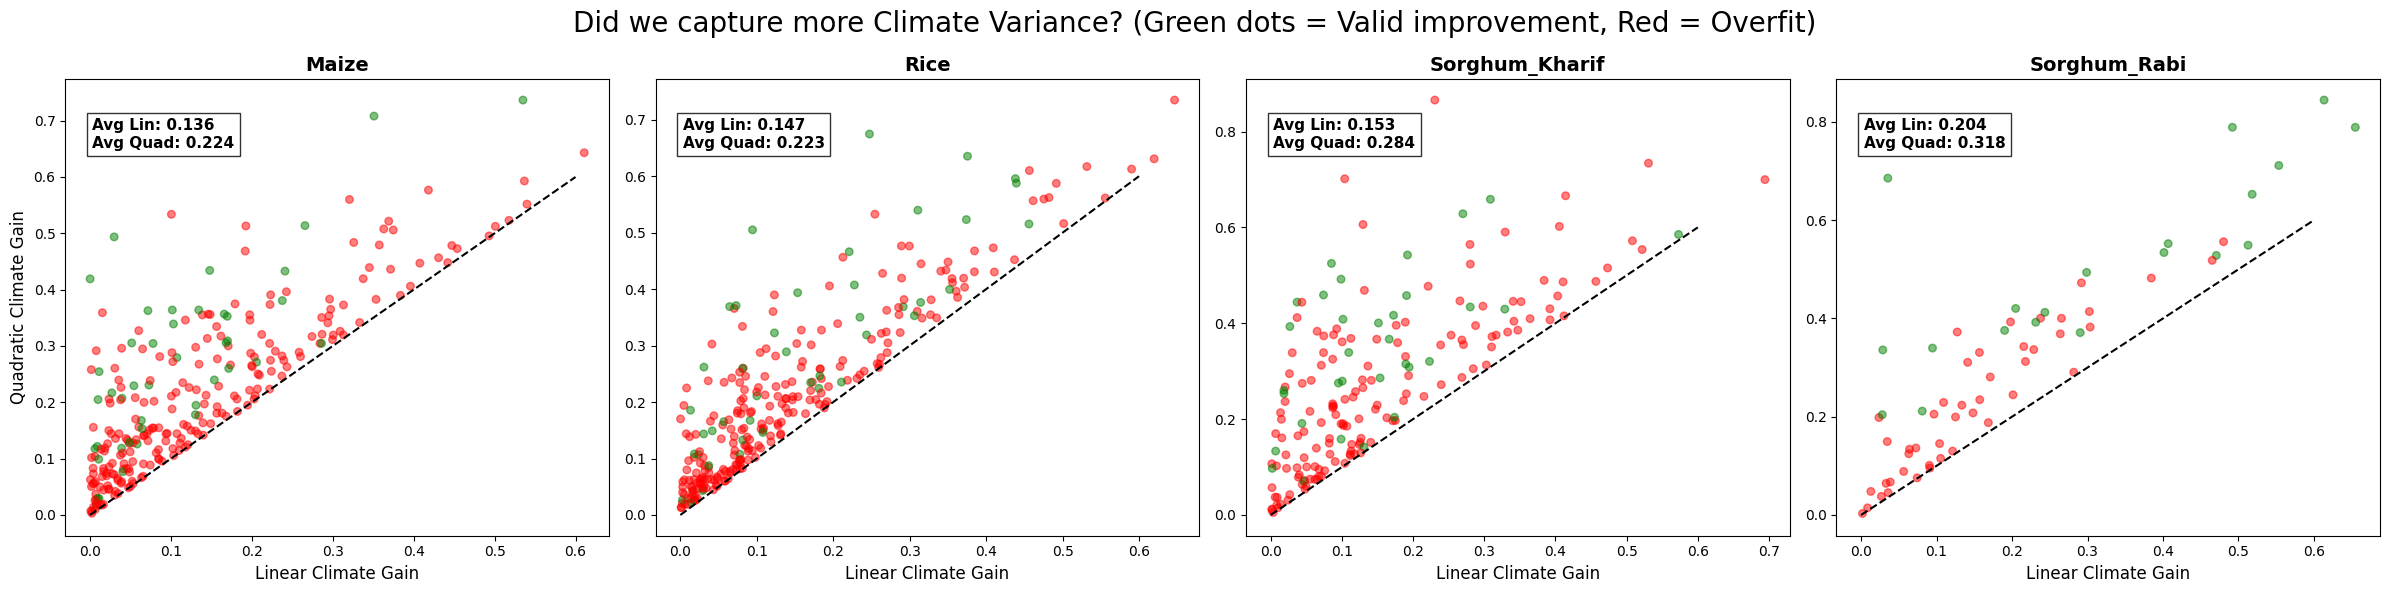

In [ ]:
# FILE: 03_Visualize_Results.ipynb
# CELL 3: The Climate Sensitivity Test

# QUESTION: Did quadratic terms capture "Extreme Weather" better?
# METRIC: Mq_Climate (Marginal Gain of Climate Variables)
# LOGIC: We expect Quad to be HIGHER (dots above line), especially for sensitive crops like Sorghum.

print("--- Sensitivity Test: Marginal Gain of Climate ---")

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for i, crop in enumerate(crops):
    ax = axes[i]
    data = merged[merged['crop'] == crop]

    # Scatter
    # Color dots by whether the CV score improved (Green) or got worse (Red)
    # This helps identify "False Gains" (where R2 went up but CV went down)
    colors = np.where(data['R2_cv_quad'] > data['R2_cv_lin'], 'green', 'red')

    ax.scatter(data['Mq_Climate_lin'], data['Mq_Climate_quad'], alpha=0.5, c=colors, s=30)

    # 1:1 Line
    lims = [0, 0.6] # Standard R2 range
    ax.plot(lims, lims, 'k--', label='Tie Line')

    # Styling
    ax.set_title(f"{crop.title()}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Linear Climate Gain", fontsize=12)

    if i == 0:
        ax.set_ylabel("Quadratic Climate Gain", fontsize=12)

    # Stats
    avg_gain_lin = data['Mq_Climate_lin'].mean()
    avg_gain_quad = data['Mq_Climate_quad'].mean()

    ax.text(0.05, 0.85, f"Avg Lin: {avg_gain_lin:.3f}\nAvg Quad: {avg_gain_quad:.3f}",
            transform=ax.transAxes, color='black', fontsize=11, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))

plt.suptitle("Did we capture more Climate Variance? (Green dots = Valid improvement, Red = Overfit)", fontsize=20, y=0.98)
plt.tight_layout()
plt.show()

In [ ]:
# FILE: 03_Visualize_Results.ipynb
# CELL 4: Final Summary Table

# Calculate the Net Impact per crop
summary = merged.groupby('crop')[['R2_cv_lin', 'R2_cv_quad', 'Mq_Climate_lin', 'Mq_Climate_quad']].mean()

# Calculate Deltas
summary['CV_Change'] = summary['R2_cv_quad'] - summary['R2_cv_lin']
summary['Climate_Power_Added'] = summary['Mq_Climate_quad'] - summary['Mq_Climate_lin']

# Format
display_cols = ['R2_cv_lin', 'R2_cv_quad', 'CV_Change', 'Climate_Power_Added']
print("--- Final Scorecard: Linear vs. Quadratic ---")
print("    CV_Change < 0 implies overfitting.")
print("    Climate_Power_Added > 0 implies non-linear responses were found.")

display(summary[display_cols].style.background_gradient(subset=['CV_Change', 'Climate_Power_Added'], cmap='RdYlGn', vmin=-0.05, vmax=0.05))

--- Final Scorecard: Linear vs. Quadratic ---
    CV_Change < 0 implies overfitting.
    Climate_Power_Added > 0 implies non-linear responses were found.


,R2_cv_lin,R2_cv_quad,CV_Change,Climate_Power_Added
crop,,,,
maize,-0.094367,-0.341242,-0.246875,0.088276
rice,0.017944,-0.266017,-0.283961,0.076039
sorghum_kharif,-0.289560,-0.475980,-0.186420,0.131045
sorghum_rabi,-0.074225,-0.268001,-0.193776,0.113523


--- Mapping Non-Linearity: Where did the Quadratic Model improve Climate detection? ---
    Metric: Mq_Climate_Quad - Mq_Climate_Lin


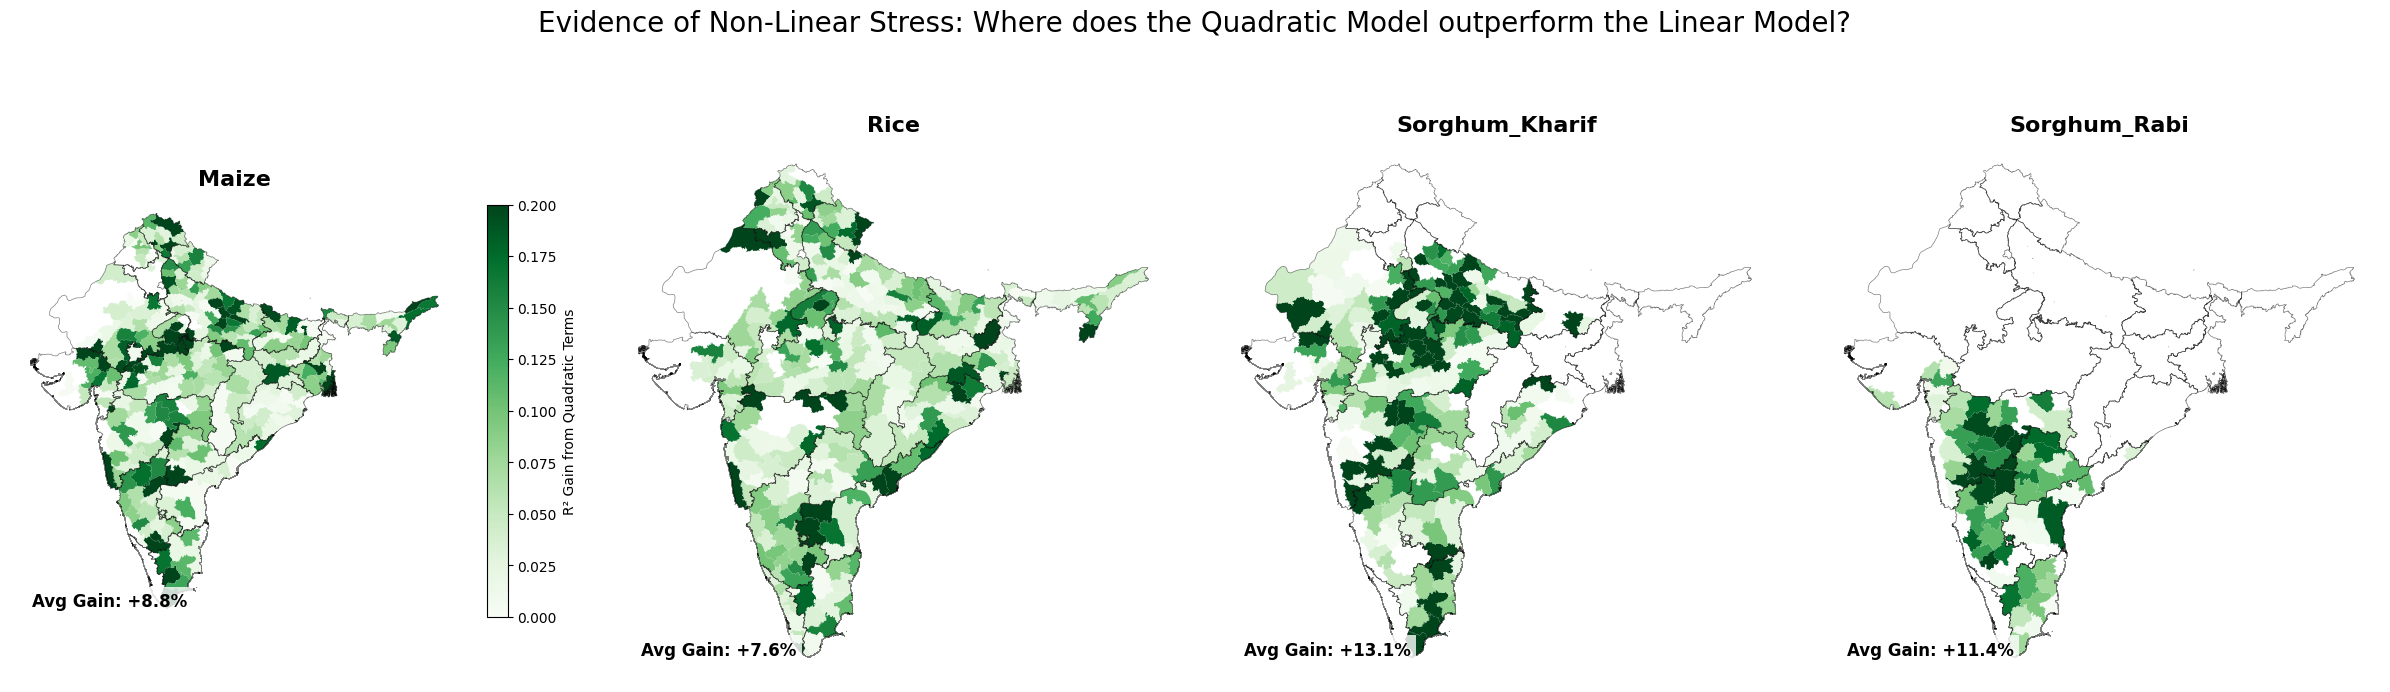

In [ ]:
# FILE: 03_Visualize_Results.ipynb
# NEW CELL: The "Non-Linearity" Map

import matplotlib.pyplot as plt

print("--- Mapping Non-Linearity: Where did the Quadratic Model improve Climate detection? ---")
print("    Metric: Mq_Climate_Quad - Mq_Climate_Lin")

# --- Configuration ---
target_shift = 0
crops = ['maize', 'rice', 'sorghum_kharif', 'sorghum_rabi']

# Load Boundaries
if 'state_boundaries_gdf' not in locals():
    import geopandas as gpd
    districts_gdf = gpd.read_file("data/processed/districts_joined.gpkg")
    state_boundaries_gdf = districts_gdf.dissolve(by='state_shp').reset_index()

# Setup Figure
fig, axes = plt.subplots(1, 4, figsize=(24, 8))

for i, crop in enumerate(crops):
    ax = axes[i]

    # 1. Get Data (Merged previously in Cell 1)
    # We filter 'merged' which has both _lin and _quad columns
    df = merged[merged['crop'] == crop].copy()

    # 2. Calculate the Gain from Non-Linearity
    df['Quadratic_Boost'] = df['Mq_Climate_quad'] - df['Mq_Climate_lin']

    # 3. Merge Geometry
    geo_data = districts_gdf.merge(df, on='Dist Code', how='inner')

    # 4. Filter Intensity (Optional, helps clean up map)
    # We can use the previously defined logic or just show all
    # Let's show all valid districts to see the pattern

    # 5. Plot
    # We use a Greens colormap. Darker Green = Stronger Non-Linearity.
    geo_data.plot(
        column='Quadratic_Boost',
        ax=ax,
        cmap='Greens',
        vmin=0, vmax=0.20, # Scale: 0% to 20% gain
        legend=(i==0),
        legend_kwds={'label': 'R² Gain from Quadratic Terms', 'shrink': 0.6}
    )

    state_boundaries_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.5, alpha=0.5)

    ax.set_title(f"{crop.title()}", fontsize=16, fontweight='bold')
    ax.set_axis_off()

    # Add stats
    avg_boost = df['Quadratic_Boost'].mean()
    ax.text(0.05, 0.05, f"Avg Gain: +{avg_boost*100:.1f}%",
            transform=ax.transAxes, fontsize=12, fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.suptitle("Evidence of Non-Linear Stress: Where does the Quadratic Model outperform the Linear Model?", fontsize=20, y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()